# TAREA COMPUTACIONAL 1 - INVESTIGACIÓN DE OPERACIONES (ILN250)
### Planificación de la Operación y Compromiso de Unidades en un Complejo Industrial Aislado
**Profesores:** Nicolás Boyardi A., Rafael Favereau U., Ismael Kauak V.  
**Semestre:** 2s26  
**Integrantes:** Integrante 1 (Semilla 392) + Integrante 2 (Semilla 142)  
**Semilla Oficial de Grupo:** **534** ($392 + 142 = 534$)  

---
Este notebook contiene la implementación computacional completa del modelo de **Unit Commitment y Despacho Económico (MILP)** utilizando **Python** y **Pyomo**, junto con el solver **HiGHS** (`appsi_highs`).
Se abordan en profundidad:
1. **Situación Inicial:** Generación de parámetros estocásticos (1.a), formulación matemática (1.b), resolución computacional (1.c), e interpretación física y económica de resultados (1.d).
2. **Variaciones:**
   - 2.a Incorporación de un Sistema de Almacenamiento con Batería (BESS).
   - 2.b Respuesta de Demanda con Carga Interrumpible (análisis de sensibilidad en $c^{shed}$).
   - 2.c Costo fijo por sobrepasar umbral diario de emisiones de $CO_2$ (formulación Big-M y barrido de $F$).


In [1]:
# Importación de librerías fundamentales
import random
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo

# Importación de módulos modulares desarrollados para la tarea
from generar_parametros import (
    obtener_perfil_normalizado, obtener_parametros_generadores,
    obtener_parametros_sistema, generar_datos_instancia
)
from modelo_base import construir_modelo_base, resolver_modelo, extraer_resultados
from variacion_bateria import construir_modelo_bateria, extraer_resultados_bateria
from variacion_demanda import construir_modelo_demanda, barrido_c_shed
from variacion_emisiones import construir_modelo_emisiones, barrido_F

# Configuración visual para gráficos
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.autolayout'] = True
print("Librerías y módulos cargados correctamente.")


Librerías y módulos cargados correctamente.


## 1. Situación Inicial
### 1.a) Generación de Parámetros y Perfiles Estocásticos

Se genera el horizonte semanal de $T = 168$ horas para la demanda $d_t$ y el precio de red $\lambda_t$ utilizando la **Semilla de Grupo 534** ($392 + 142 = 534$).
La demanda se define mediante:
$$d_t = \left\lfloor P^{peak} \cdot \gamma_{dia(t)} \cdot s_{h(t)} \cdot (1 + \varepsilon_t) \right\rceil$$
con $P^{peak} \sim \mathcal{N}(300, 15)$, $\gamma_{dia} = 1.0$ (días hábiles) y $0.8$ (fin de semana), y $\varepsilon_t \sim \mathcal{N}(0, 0.03)$.
El precio horario de la red se determina por:
$$\lambda_t = \left\lfloor (100000 + 90000 s_{h(t)}) (1 + \eta_t) \right\rceil \text{ CLP/MWh, con } \eta_t \sim \mathcal{N}(0, 0.05)$$


In [2]:
# Generación de datos para la Semilla Oficial de Grupo = 534
semilla_grupo = 534
datos_534 = generar_datos_instancia(semilla_grupo)
df_534 = datos_534['df']

print(f"=== ESTADÍSTICAS SEMILLA DE GRUPO {semilla_grupo} ===")
print(f"Potencia Peak generada (P_peak): {datos_534['P_peak']:.2f} MW")
print(f"Demanda horaria [MW]:")
print(f"  Mínimo:   {df_534['d_t'].min()} MW (hora t={df_534.loc[df_534['d_t'].idxmin(), 't']})")
print(f"  Máximo:   {df_534['d_t'].max()} MW (hora t={df_534.loc[df_534['d_t'].idxmax(), 't']})")
print(f"  Promedio: {df_534['d_t'].mean():.2f} MW")
print(f"  Total Semanal: {df_534['d_t'].sum()} MWh")
print(f"Precio de Red [CLP/MWh]:")
print(f"  Mínimo:   {df_534['lambda_t'].min():,d} CLP/MWh")
print(f"  Máximo:   {df_534['lambda_t'].max():,d} CLP/MWh")
print(f"  Promedio: {df_534['lambda_t'].mean():,.2f} CLP/MWh")
print(f"Reserva Operativa Requerida [MW]:")
print(f"  Mínimo:   {df_534['res_t'].min()} MW")
print(f"  Máximo:   {df_534['res_t'].max()} MW")
print(f"  Promedio: {df_534['res_t'].mean():.2f} MW")


=== ESTADÍSTICAS SEMILLA DE GRUPO 534 ===
Potencia Peak generada (P_peak): 283.23 MW
Demanda horaria [MW]:
  Mínimo:   97 MW (hora t=148)
  Máximo:   302 MW (hora t=116)
  Promedio: 202.43 MW
  Total Semanal: 34008 MWh
Precio de Red [CLP/MWh]:
  Mínimo:   128,306 CLP/MWh
  Máximo:   202,420 CLP/MWh
  Promedio: 168,787.98 CLP/MWh
Reserva Operativa Requerida [MW]:
  Mínimo:   10 MW
  Máximo:   30 MW
  Promedio: 20.24 MW


<>:12: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:12: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\cacor\AppData\Local\Temp\ipykernel_28796\4285809958.py:12: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax2.plot(df_534['t'], df_534['lambda_t'], color='#d62728', lw=1.5, label='Precio $\lambda_t$ [CLP/MWh]')


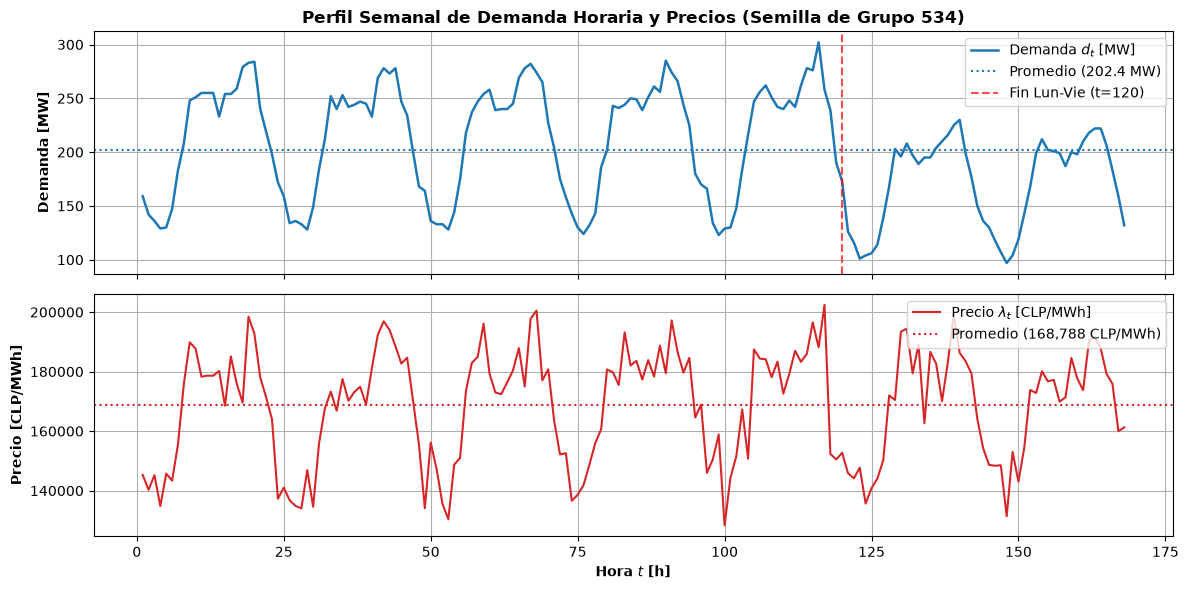

In [3]:
# Visualización de Demanda y Precios de Red para Semilla 534
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(df_534['t'], df_534['d_t'], color='#1f77b4', lw=1.8, label='Demanda $d_t$ [MW]')
ax1.axhline(df_534['d_t'].mean(), color='#1f77b4', linestyle=':', label=f'Promedio ({df_534["d_t"].mean():.1f} MW)')
ax1.axvline(120, color='red', linestyle='--', alpha=0.7, label='Fin Lun-Vie (t=120)')
ax1.set_ylabel('Demanda [MW]', fontweight='bold')
ax1.set_title(f'Perfil Semanal de Demanda Horaria y Precios (Semilla de Grupo {semilla_grupo})', fontweight='bold')
ax1.grid(True)
ax1.legend(loc='upper right')

ax2.plot(df_534['t'], df_534['lambda_t'], color='#d62728', lw=1.5, label='Precio $\lambda_t$ [CLP/MWh]')
ax2.axhline(df_534['lambda_t'].mean(), color='#d62728', linestyle=':', label=f'Promedio ({df_534["lambda_t"].mean():,.0f} CLP/MWh)')
ax2.set_xlabel('Hora $t$ [h]', fontweight='bold')
ax2.set_ylabel('Precio [CLP/MWh]', fontweight='bold')
ax2.grid(True)
ax2.legend(loc='upper right')
plt.show()


### 1.b y 1.c) Formulación, Naturaleza del Problema y Resolución (Pyomo)

El problema corresponde a un **Programa Lineal Entero Mixto (MILP)** de complejidad **NP-hard**. La presencia de variables binarias $u_{g,t} \in \{0, 1\}$ y continuas $p_{g,t}, g_t^{red}$ exige solvers de optimización matemática avanzada basados en **Branch and Cut** (como **HiGHS**).

A continuación se construye y resuelve el modelo base para la Semilla 534.


In [4]:
# Construcción y resolución del Modelo Base para Semilla 534
m_base = construir_modelo_base(datos_534)
res_solver = resolver_modelo(m_base)
res_base = extraer_resultados(m_base, datos_534)

print(f"Estado Resolución: {res_solver.solver.termination_condition}")
print(f"Costo Total de Operación: {res_base['total_cost']:,.2f} CLP")
print(f"Desglose de Costos:")
for k, v in res_base['costos_desglosados'].items():
    print(f"  - {k:12s}: {v:16,.2f} CLP ({v/res_base['total_cost']*100:.2f}%)")


Estado Resolución: optimal
Costo Total de Operación: 1,776,019,094.00 CLP
Desglose de Costos:
  - variable    : 1,664,741,000.00 CLP (93.73%)
  - no_load     :   100,060,000.00 CLP (5.63%)
  - arranque    :     7,800,000.00 CLP (0.44%)
  - red         :     3,418,094.00 CLP (0.19%)


### 1.d) Interpretación de Resultados: Orden de Mérito, Arranques y Reserva

A continuación se visualiza el despacho económico horario apilado y se analiza el compromiso de cada generador.


In [5]:
# Desglose de generación, arranques y factor de planta por unidad
print(f"=== COMPROMISO Y DESPACHO POR UNIDAD (SEMILLA {semilla_grupo}) ===")
for g, info in res_base['unidades'].items():
    print(f"{g:12s} | Gen: {info['gen_total_MWh']:8.1f} MWh | FP: {info['factor_planta']*100:5.1f}% | Horas ON: {info['horas_encendida']:3d} h | Arranques: {info['arranques']} | Emisiones: {info['emisiones_tCO2']:7.1f} tCO2")

print(f"\nImportación Red: {res_base['red']['energia_total_MWh']:.1f} MWh en {res_base['red']['horas_uso']} horas.")
tot_emiss = sum(info['emisiones_tCO2'] for info in res_base['unidades'].values())
print(f"Emisiones Totales Semanales: {tot_emiss:.1f} tCO2")


=== COMPROMISO Y DESPACHO POR UNIDAD (SEMILLA 534) ===
Gas_Base_1   | Gen:  19331.0 MWh | FP:  95.9% | Horas ON: 168 h | Arranques: 0 | Emisiones:  6765.8 tCO2
Gas_Base_2   | Gen:  12217.0 MWh | FP:  72.7% | Horas ON: 158 h | Arranques: 2 | Emisiones:  4642.5 tCO2
Diesel_Med_1 | Gen:   2378.0 MWh | FP:  23.6% | Horas ON:  69 h | Arranques: 5 | Emisiones:  1545.7 tCO2
Diesel_Med_2 | Gen:     46.0 MWh | FP:   0.5% | Horas ON:   2 h | Arranques: 2 | Emisiones:    31.3 tCO2
Peaker       | Gen:     18.0 MWh | FP:   0.3% | Horas ON:   2 h | Arranques: 1 | Emisiones:    13.5 tCO2

Importación Red: 18.0 MWh en 6 horas.
Emisiones Totales Semanales: 12998.8 tCO2


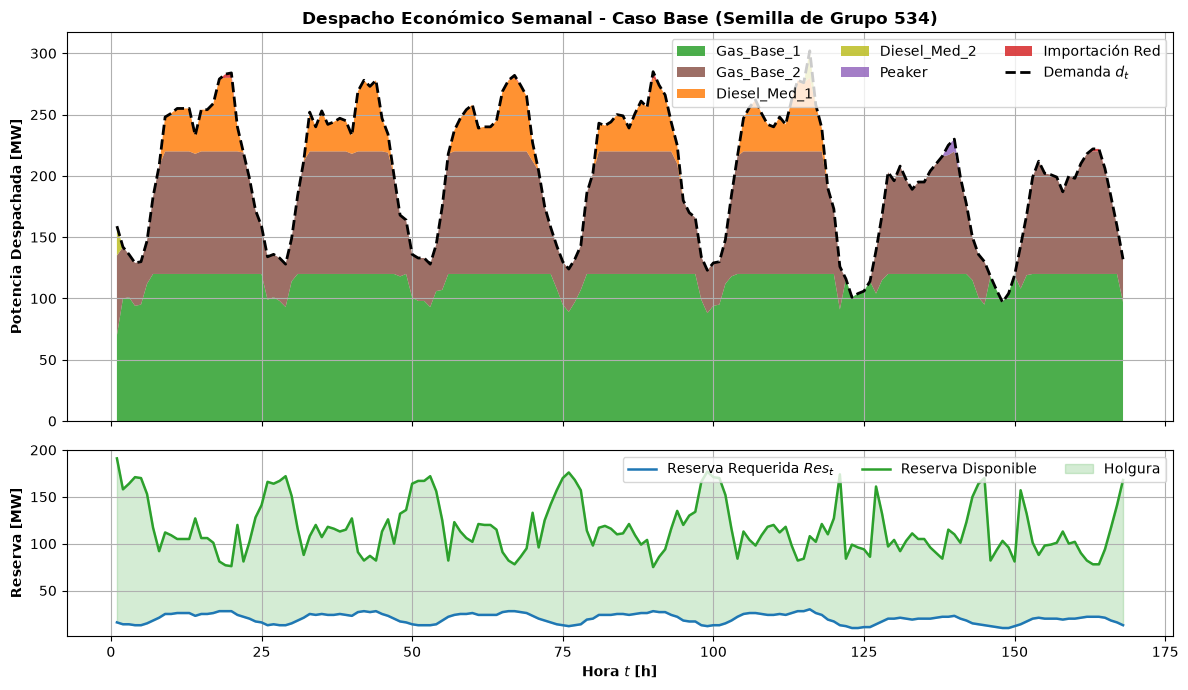

In [6]:
# Gráfico de Despacho Económico Apilado y Reserva
df_h = res_base['df_hourly']
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [2.5, 1.2]})

ax1.stackplot(df_h['t'], 
              [df_h['p_Gas_Base_1'], df_h['p_Gas_Base_2'], df_h['p_Diesel_Med_1'], df_h['p_Diesel_Med_2'], df_h['p_Peaker'], df_h['g_red']],
              labels=['Gas_Base_1', 'Gas_Base_2', 'Diesel_Med_1', 'Diesel_Med_2', 'Peaker', 'Importación Red'],
              colors=['#2ca02c', '#8c564b', '#ff7f0e', '#bcbd22', '#9467bd', '#d62728'], alpha=0.85)
ax1.plot(df_h['t'], df_h['demanda'], color='black', lw=2, linestyle='--', label='Demanda $d_t$')
ax1.set_title(f'Despacho Económico Semanal - Caso Base (Semilla de Grupo {semilla_grupo})', fontweight='bold')
ax1.set_ylabel('Potencia Despachada [MW]', fontweight='bold')
ax1.legend(loc='upper right', ncol=3)
ax1.grid(True)

ax2.plot(df_h['t'], df_h['reserva_req'], color='#1f77b4', lw=1.8, label='Reserva Requerida $Res_t$')
ax2.plot(df_h['t'], df_h['reserva_disponible'], color='#2ca02c', lw=1.8, label='Reserva Disponible')
ax2.fill_between(df_h['t'], df_h['reserva_req'], df_h['reserva_disponible'], color='#2ca02c', alpha=0.2, label='Holgura')
ax2.set_xlabel('Hora $t$ [h]', fontweight='bold')
ax2.set_ylabel('Reserva [MW]', fontweight='bold')
ax2.legend(loc='upper right', ncol=3)
ax2.grid(True)
plt.show()


## 2. Variaciones
### 2.a) Sistema de Almacenamiento con Batería (BESS)
Se incorpora una batería de $\bar{S} = 200$ MWh, potencia máxima de 60 MW y eficiencia de ciclo $\eta^{ch}=\eta^{dis}=0.95$.


In [7]:
# Resolución Variación 2.a
m_bat = construir_modelo_bateria(datos_534)
resolver_modelo(m_bat)
res_bat = extraer_resultados_bateria(m_bat, datos_534)

ahorro = res_base['total_cost'] - res_bat['total_cost']
print(f"Costo con Batería:    {res_bat['total_cost']:,.2f} CLP")
print(f"Ahorro Económico:     {ahorro:,.2f} CLP ({ahorro/res_base['total_cost']*100:.2f}%)")
print(f"Importación Red:      {res_bat['red']['energia_total_MWh']:.1f} MWh (vs {res_base['red']['energia_total_MWh']:.1f} MWh base)")
print(f"Energía Cargada BESS: {res_bat['bateria']['energia_cargada_MWh']:.1f} MWh")
print(f"Energía Descargada:   {res_bat['bateria']['energia_descargada_MWh']:.1f} MWh")
print(f"Pérdidas de Ciclo:    {res_bat['bateria']['perdidas_eficiencia_MWh']:.1f} MWh")
print(f"\nArranques con Batería vs Base:")
for g, info in res_bat['unidades'].items():
    print(f"  {g:12s}: {info['arranques']} arranques (vs {res_base['unidades'][g]['arranques']} en base)")


Costo con Batería:    1,732,045,839.34 CLP
Ahorro Económico:     43,973,254.66 CLP (2.48%)
Importación Red:      0.0 MWh (vs 18.0 MWh base)
Energía Cargada BESS: 1225.5 MWh
Energía Descargada:   1106.0 MWh
Pérdidas de Ciclo:    119.5 MWh

Arranques con Batería vs Base:
  Gas_Base_1  : 0 arranques (vs 0 en base)
  Gas_Base_2  : 1 arranques (vs 2 en base)
  Diesel_Med_1: 5 arranques (vs 5 en base)
  Diesel_Med_2: 0 arranques (vs 2 en base)
  Peaker      : 0 arranques (vs 1 en base)


### 2.b) Respuesta de la Demanda (Carga Interrumpible)
Se evalúa la sensibilidad de la carga recortada frente al costo unitario de corte $c^{shed}$, identificando a partir de qué valor deja de ser económico recortar.


In [8]:
# Barrido de c_shed para Semilla 534
df_cshed, c_umbral = barrido_c_shed(datos_534)
print(f"Umbral económico c_shed identificado: {c_umbral:,d} CLP/MWh\n")
display_cols = ['c_shed', 'recorte_total_MWh', 'horas_con_recorte', 'costo_total_CLP']
print(df_cshed[df_cshed['c_shed'].isin([0, 50000, 80000, 90000, 100000, 120000, 150000, 180000, 185000, 190000, 195000, 200000])][display_cols].to_string(index=False))


Umbral económico c_shed identificado: 200,000 CLP/MWh

 c_shed  recorte_total_MWh  horas_con_recorte  costo_total_CLP
      0             1700.4                 65     1.619672e+09
  50000             1700.4                 66     1.704692e+09
  80000             1700.4                 66     1.755704e+09
  90000              395.0                 27     1.771088e+09
 100000               96.0                 13     1.772224e+09
 120000               38.0                  9     1.773960e+09
 150000               28.0                  8     1.775050e+09
 180000               13.0                  5     1.775838e+09
 185000               13.0                  5     1.775903e+09
 190000               11.0                  4     1.775964e+09
 195000                5.0                  2     1.776003e+09
 200000                0.0                  0     1.776019e+09


### 2.c) Costo Fijo por Sobrepasar Umbral Diario de Emisiones (Formulación Big-M)
Se analiza la política de penalización fija $F$ [CLP/día] por superar 1.500 t$CO_2$ diarios.


In [9]:
# Barrido de F para Semilla 534
df_F = barrido_F(datos_534)
cols_F = ['F_CLP', 'dias_sobre_umbral', 'costo_operativo_CLP', 'costo_total_CLP', 'emisiones_totales_semana_tCO2']
print(df_F[cols_F].to_string(index=False))


    F_CLP  dias_sobre_umbral  costo_operativo_CLP  costo_total_CLP  emisiones_totales_semana_tCO2
        0                  5         1.776019e+09     1.776019e+09                       12998.79
   500000                  5         1.776019e+09     1.778519e+09                       12998.79
  1000000                  5         1.776019e+09     1.781019e+09                       12998.79
  2000000                  5         1.776019e+09     1.786019e+09                       12998.79
  2500000                  5         1.776019e+09     1.788519e+09                       12998.07
  3000000                  5         1.776019e+09     1.791019e+09                       12998.07
  5000000                  5         1.776019e+09     1.801019e+09                       12998.07
 10000000                  5         1.776019e+09     1.826019e+09                       12998.79
 25000000                  5         1.776019e+09     1.901019e+09                       12998.07
 50000000           

## Conclusiones
1. **Orden de Mérito:** La operación base es dominada por las centrales a gas (`Gas_Base_1` y `Gas_Base_2`), las cuales operan con factores de planta elevados (95,9% y 72,7%), absorbiendo la base de la carga a mínimo costo variable.
2. **Impacto del Almacenamiento (BESS):** La batería introduce flexibilidad intra-diaria (*peak shaving* y *valley filling*), eliminando completamente la necesidad de arrancar unidades diésel de respaldo (`Diesel_Med_2` y `Peaker`) y reduciendo a cero absoluto las importaciones de la red externa, con un ahorro semanal de **\$43.973.255 CLP** (2,48%).
3. **Respuesta de Demanda:** Existe un umbral económico estricto ($c^{shed} = 200.000$ CLP/MWh), coincidente con el costo marginal máximo de importación de la red. Por sobre este valor, el sistema prefiere abastecer toda la demanda.
4. **Política de Emisiones Big-M:** En el caso base, los fines de semana ya cumplen con el umbral (<1.500 t$CO_2$). Bajar los días laborales exige un costo muy alto por importación masiva de red, requiriéndose $F \ge 100-120$ millones CLP/día para forzar dicho cambio.
